# Minimal LLLA-based Gas Exploration Strategy

This script illustrates the use of the Last-Layer-Laplace-Approxoimation (LLLA) based exploration strategy. 

It considers the domain geometry and wind conditions to be known and only focuses on gas exploration. 
Additionally, a few gas measurements are assumed to be known from the beginning.
Subsequent measurements points are then derived from the LLLA exploration aiming to reduce global source term uncertainty outlined in the [LLLA Documentation](../docs/joint_last_layer_laplace.md).

> **__NOTE__**: This example does not yet include the actual path length to choose the optimal next measurement point (TODO).

In [47]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.interpolate import NearestNDInterpolator

root = Path.cwd()
if not (root / "source_estimation_pinn").exists():
    root = root.parent
sys.path.insert(0, str(root))

from source_estimation_pinn.environment import OccupancyGrid, WindField
from source_estimation_pinn.measurements import GasSampleSet
from source_estimation_pinn.estimation import GasSourceConfig, GasSourceEstimator

In [41]:
mesh_path = root / "data/example_labyrinth/labyrinth_2d_fine.msh"
wind_path = root / "data/example_labyrinth/wind_gt.csv"
gas_path = root / "data/example_labyrinth/gas_gt1.5_2.0.csv"
true_source = np.array([1.5, 2.0])

occupancy = OccupancyGrid.from_msh_file(mesh_path, resolution=0.1)
wind = WindField.from_csv(wind_path)
gas_reference = GasSampleSet.from_csv(gas_path)
sensor_oracle = NearestNDInterpolator(
    gas_reference.positions,
    gas_reference.concentrations,
)

candidate_points = occupancy.free_points
reference_concentration = np.asarray(sensor_oracle(candidate_points))

# Coverage route followed until it contains several nonzero detections.
route_targets = np.vstack((
    np.column_stack((np.linspace(4, 6, 6), np.full(6, 1.5))),
    np.column_stack((np.full(6, 5.0), np.linspace(0.5, 2.5, 6))),
))
squared_distances = np.sum(
    (route_targets[:, None, :] - gas_reference.positions[None, :, :]) ** 2,
    axis=2,
)
nearest_indices = np.argmin(squared_distances, axis=1)
_, first_occurrence = np.unique(nearest_indices, return_index=True)
nearest_indices = nearest_indices[np.sort(first_occurrence)]
initial_samples = GasSampleSet(
    positions=gas_reference.positions[nearest_indices],
    concentrations=gas_reference.concentrations[nearest_indices],
)

detection_threshold = 1e-3
print(f"Initial measurements: {len(initial_samples.positions)}")
print(f"Detections above {detection_threshold:g}: "
      f"{np.count_nonzero(initial_samples.concentrations > detection_threshold)}")
print(f"Maximum measured concentration: "
      f"{initial_samples.concentrations.max():.4e}")


Initial measurements: 12
Detections above 0.001: 12
Maximum measured concentration: 2.8360e-02


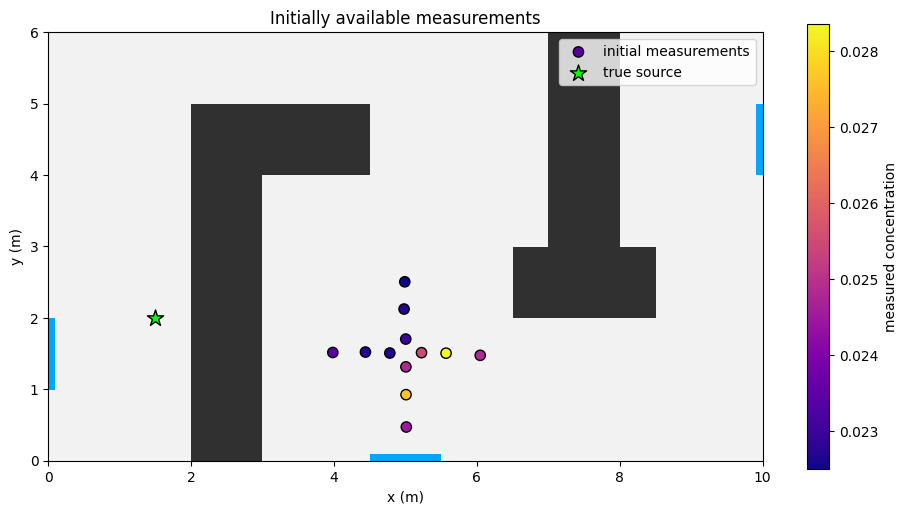

In [42]:
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
occupancy.plot(ax=ax, title="Initially available measurements")
if ax.get_legend() is not None:
    ax.get_legend().remove()
measurements = ax.scatter(
    *initial_samples.positions.T, c=initial_samples.concentrations,
    cmap="plasma", s=55, edgecolor="black", label="initial measurements", zorder=4,
)
ax.scatter(*true_source, marker="*", s=150, color="lime", edgecolor="black",
           label="true source", zorder=5, clip_on=False)
fig.colorbar(measurements, ax=ax, label="measured concentration")
ax.legend(loc="best")
plt.show()


In [43]:
config = GasSourceConfig(
    concentration_hidden_layers=3,
    concentration_hidden_dim=32,
    source_hidden_layers=3,
    source_hidden_dim=16,
    diffusion_constant=1e-3,
    lambda_sparse=1e-4,
    lambda_nonfree=1e-2,
    # The earlier value 1e-3 noticeably distorted the tiny gas-loss scale.
    last_layer_prior_precision=1e-6,
    learning_rate=2e-3,
)

model_seed = 7
initial_training_steps = 1800
update_training_steps = 300    # continued training after each measurement
n_collocation_points = min(1000, len(candidate_points))

torch.manual_seed(model_seed)
estimator = GasSourceEstimator(occupancy=occupancy, wind=wind, config=config)
samples = GasSampleSet(initial_samples.positions.copy(), initial_samples.concentrations.copy())
estimator.fit(samples, steps=initial_training_steps,
              n_collocation_points=n_collocation_points)


EstimationHistory(losses={'total': array([6.00571861e-04, 5.95731894e-04, 5.90393087e-04, ...,
       3.96368414e-05, 3.90748464e-05, 3.91860958e-05], shape=(1800,)), 'gas_data': array([5.50419849e-04, 5.45520277e-04, 5.40070992e-04, ...,
       2.42287865e-06, 2.57489705e-06, 2.53358553e-06], shape=(1800,)), 'ad': array([8.35786125e-07, 7.64715196e-07, 7.09354310e-07, ...,
       3.92488573e-06, 3.30032140e-06, 3.40738370e-06], shape=(1800,)), 'gas_wall': array([4.86369112e-10, 7.88368204e-10, 1.28174349e-09, ...,
       5.14168232e-06, 5.05919706e-06, 5.09132587e-06], shape=(1800,)), 'inflow': array([9.87409294e-07, 1.15156547e-06, 1.34845391e-06, ...,
       7.89493583e-07, 7.90950423e-07, 7.99309248e-07], shape=(1800,)), 'sparse': array([9.18434182e-08, 8.81466704e-08, 8.54990603e-08, ...,
       2.39483484e-07, 2.40035916e-07, 2.54455244e-07], shape=(1800,)), 'nonfree': array([8.55364313e-09, 7.93548249e-09, 7.37376604e-09, ...,
       1.89864089e-08, 1.95792271e-08, 2.00347010e-0

In [44]:
# Exclude candidate cells already covered by the initial measurements.
selected = set(np.argmin(np.sum(
    (samples.positions[:, None, :] - candidate_points[None, :, :]) ** 2,
    axis=2,
), axis=1))
n_acquisitions = 15             # additional measurements
acquired_positions = []
source_errors = [np.linalg.norm(estimator.get_source_estimate() - true_source)]

for acquisition in range(n_acquisitions):
    covariance = estimator.laplace.compute_covariance()
    torch.linalg.cholesky(covariance)  # stop if the covariance is invalid
    with torch.no_grad():
        scores = estimator.source_uncertainty_reduction(
            candidate_points, source_eval_points=candidate_points
        ).cpu().numpy()
    if not np.all(np.isfinite(scores)) or np.any(scores < 0):
        raise RuntimeError("Expected finite, nonnegative Laplace scores")
    scores[list(selected)] = -np.inf
    if not np.any(np.isfinite(scores)):
        raise RuntimeError("No unmeasured candidate points remain")
    index = int(np.argmax(scores))
    position = candidate_points[index].copy()
    concentration = float(np.asarray(sensor_oracle(position)).item())
    samples.append(position, concentration)
    selected.add(index)
    acquired_positions.append(position)

    estimator.fit(samples, steps=update_training_steps,
                  n_collocation_points=n_collocation_points)
    source_errors.append(np.linalg.norm(estimator.get_source_estimate() - true_source))
    print(f"Measurement {acquisition + 1}/{n_acquisitions}: {position}", flush=True)

acquired_positions = np.asarray(acquired_positions).reshape(-1, 2)
estimated_source = estimator.get_source_estimate()  # argmax q on free cells
print(f"Source error: {np.linalg.norm(estimated_source - true_source):.3f} m")


Measurement 1/15: [5.65 3.55]
Measurement 2/15: [7.75 0.95]
Measurement 3/15: [6.55 0.55]
Measurement 4/15: [5.45 0.15]
Measurement 5/15: [4.85 4.55]
Measurement 6/15: [1.25 2.05]
Measurement 7/15: [5.05 0.15]
Measurement 8/15: [6.25 2.85]
Measurement 9/15: [5.65 3.85]
Measurement 10/15: [1.55 3.15]
Measurement 11/15: [1.55 3.25]
Measurement 12/15: [1.55 3.05]
Measurement 13/15: [1.65 3.15]
Measurement 14/15: [1.85 2.95]
Measurement 15/15: [1.75 2.75]
Source error: 0.158 m


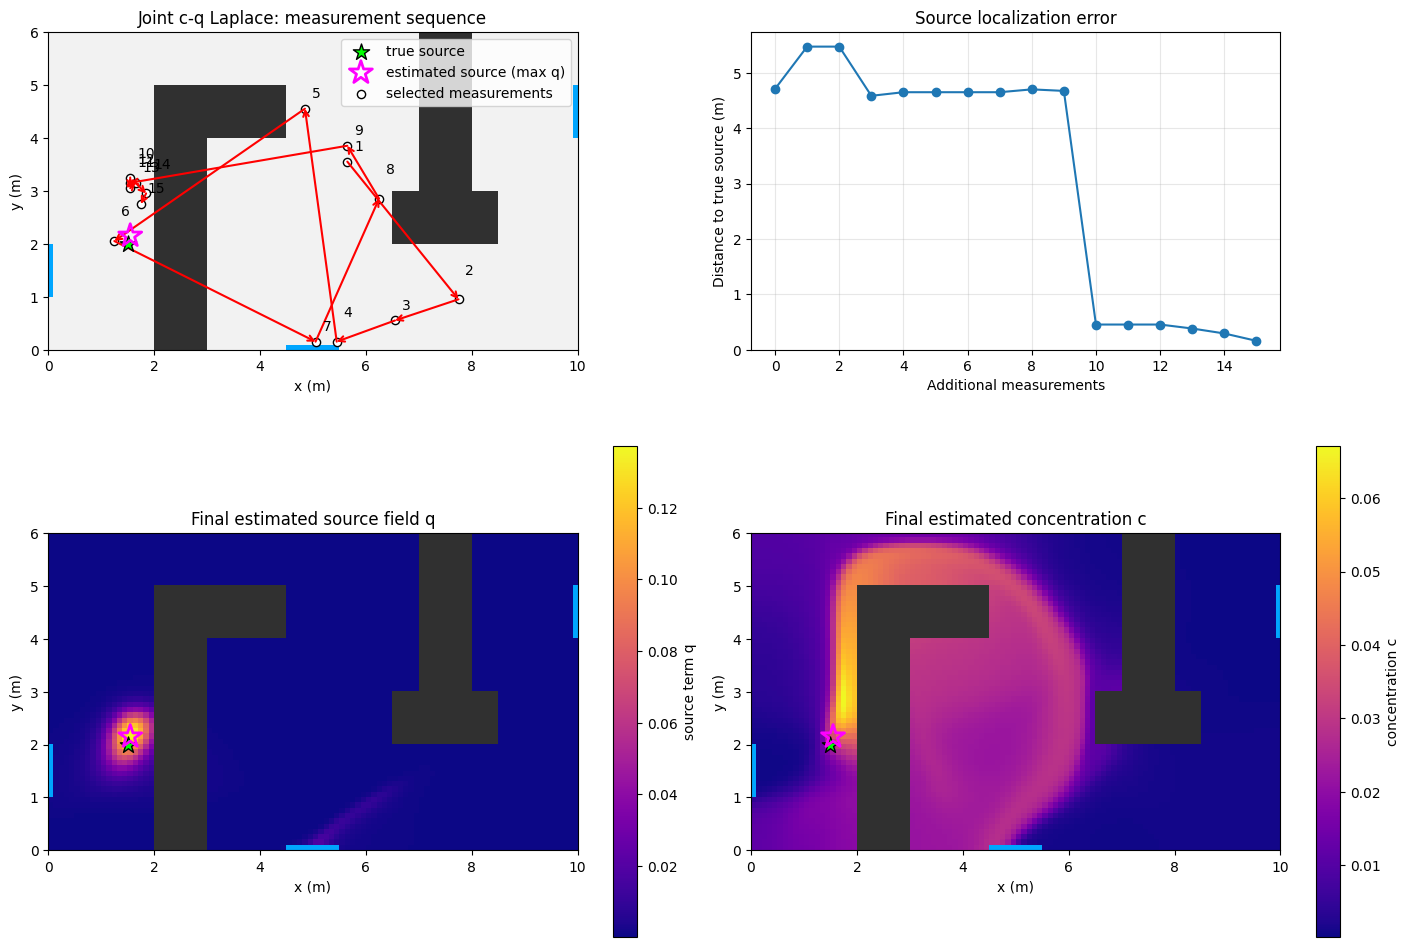

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for ax, title in (
    (axes[0, 0], "Joint c-q Laplace: measurement sequence"),
    (axes[1, 0], "Final estimated source field q"),
    (axes[1, 1], "Final estimated concentration c"),
):
    occupancy.plot(ax=ax, title=title)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.scatter(*true_source, marker="*", s=150, color="lime", edgecolor="black",
               label="true source", zorder=6, clip_on=False)
    ax.scatter(*estimated_source, marker="*", s=300, facecolors="none",
               edgecolors="magenta", linewidths=2,
               label="estimated source (max q)", zorder=7, clip_on=False)

ax = axes[0, 0]
for start, end in zip(acquired_positions[:-1], acquired_positions[1:]):
    ax.annotate("", xy=end, xytext=start,
                arrowprops=dict(arrowstyle="->", color="red", lw=1.5,
                                shrinkA=0, shrinkB=0), zorder=5)
if len(acquired_positions):
    ax.scatter(*acquired_positions.T, color="white", edgecolor="black",
               s=35, label="selected measurements", zorder=4)
    for number, position in enumerate(acquired_positions, start=1):
        ax.annotate(str(number), position, xytext=(5, 8 if number % 2 else 18),
                    textcoords="offset points", color="black", zorder=5)
ax.legend(loc="best")

axes[0, 1].plot(np.arange(len(source_errors)), source_errors, "o-")
axes[0, 1].set(title="Source localization error", xlabel="Additional measurements",
               ylabel="Distance to true source (m)", ylim=(0, None))
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_box_aspect(occupancy.free_mask.shape[0] / occupancy.free_mask.shape[1])

extent = [occupancy.lower_bound[0], occupancy.upper_bound[0],
          occupancy.lower_bound[1], occupancy.upper_bound[1]]
for ax, values, label in (
    (axes[1, 0], estimator.predict_source(candidate_points), "source term q"),
    (axes[1, 1], estimator.predict_concentration(candidate_points), "concentration c"),
):
    field = np.full(occupancy.free_mask.shape, np.nan)
    field[occupancy.free_mask] = np.asarray(values).reshape(-1)
    image = ax.imshow(field, origin="lower", extent=extent,
                      cmap="plasma", interpolation="nearest", zorder=2)
    fig.colorbar(image, ax=ax, label=label)
plt.show()
